# Lab 3 — Data Analysis and Visualization
### Chart types, misleading visuals, accessibility, and color choices
**Dataset:** Sample Superstore (retail orders, sales, profit, discount)

This notebook walks through all the lab tasks on the Superstore dataset. Each section
has a short plain-English explanation before the code, so it's clear what's being done
and why, not just what the chart looks like.


## Setup

First we load the libraries we need and read in the data. The `Order Date` column comes
in as plain text (like `11/8/2016`), so we convert it into an actual date type. That's
what lets us group orders by month later on.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Load the dataset (latin1 encoding because of a couple of special characters in city names)
df = pd.read_csv("Sample_-_Superstore.csv", encoding="latin1")

# Turn the date columns into real dates instead of text
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum()}, Duplicate rows: {df.duplicated().sum()}")
df.head()


Rows: 9994, Columns: 21
Missing values: 0, Duplicate rows: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


A quick helper we reuse on every monthly chart: instead of a handful of sparse
date labels like "2016-01", this prints every single month as its own label (e.g. "Jan 2016",
"Feb 2016", ...), rotated vertically so 48 of them still fit without overlapping.


In [2]:

def label_every_month(ax):
    # Force the x-axis to show one tick per individual month, labeled like "Jan 2016".
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=90, ha="center", fontsize=7)


The dataset turns out to be clean already — no missing values and no duplicate rows.
So "cleaning" here just means fixing the date columns and saving a tidy copy for
submission (done at the end of the notebook).


## Task 1 — Same data, three chart types

We take the monthly sales totals and plot them three different ways: bar, line, and pie.
The point of this exercise is to see that the same numbers can look completely different
depending on the chart type, and that some chart types are just the wrong tool for the job.


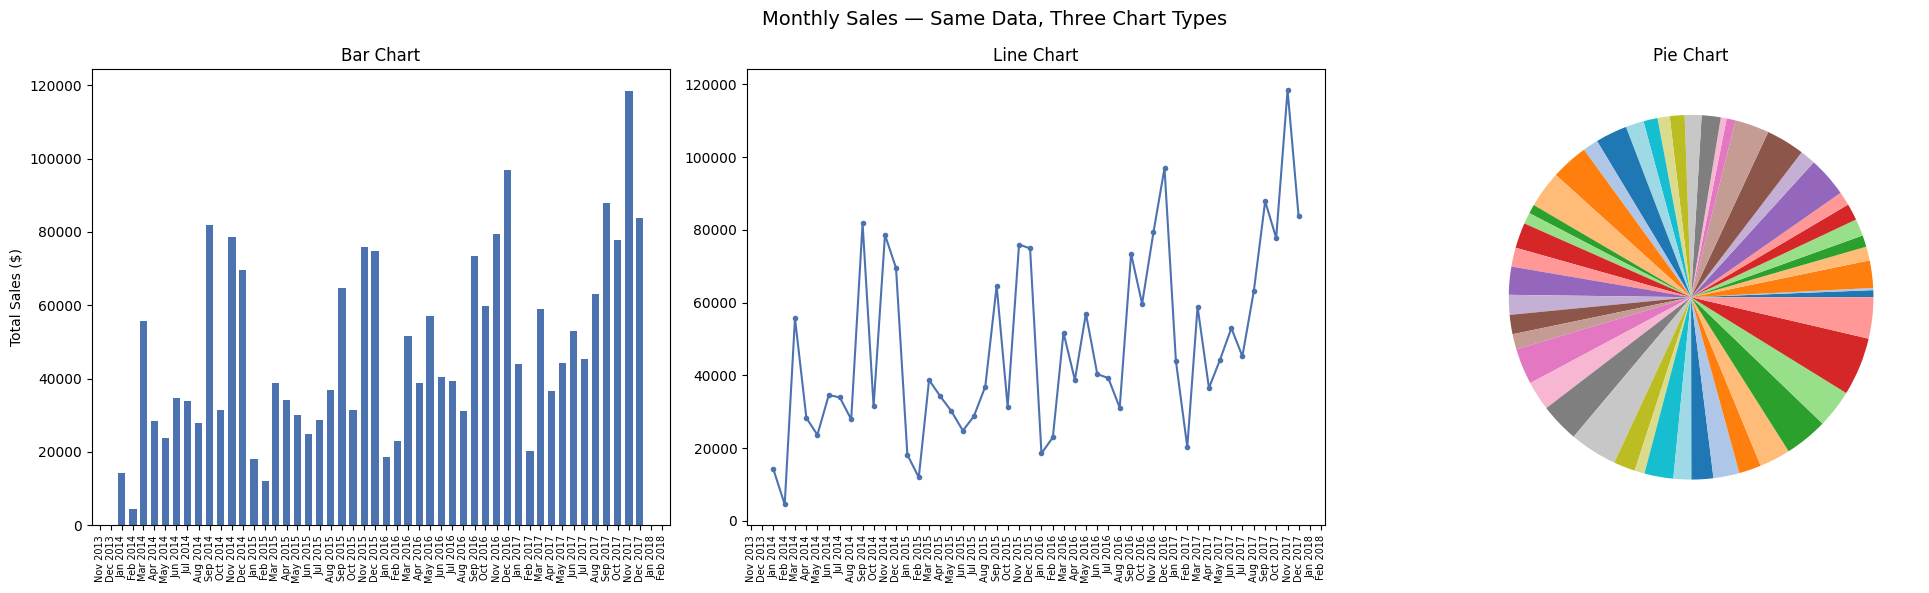

In [3]:

# Total sales grouped by month
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Bar chart
axes[0].bar(monthly_sales.index, monthly_sales.values, width=20, color="#4C72B0")
axes[0].set_title("Bar Chart")
axes[0].set_ylabel("Total Sales ($)")
label_every_month(axes[0])

# Line chart
axes[1].plot(monthly_sales.index, monthly_sales.values, color="#4C72B0", marker="o", markersize=3)
axes[1].set_title("Line Chart")
label_every_month(axes[1])

# Pie chart (splits the 48 months into slices, deliberately a bad idea, see explanation below)
axes[2].pie(monthly_sales.values, labels=None, colors=plt.cm.tab20.colors)
axes[2].set_title("Pie Chart")

plt.suptitle("Monthly Sales — Same Data, Three Chart Types", fontsize=14)
plt.tight_layout()
plt.show()


**Which chart shows the trend best, and which one hides it?**

The **line chart** shows the trend best. A trend is about direction and change over time,
and a line naturally draws your eye left to right, so you immediately see the ups, downs,
and the general upward drift by the end of the data.

The **bar chart** does an okay job too, you can still see the shape, but with 48 months
of bars packed together it gets visually noisy and harder to read than the line.

The **pie chart** hides the trend completely. Pie charts show proportion of a whole, not
change over time, and cramming 48 months into one pie means you get 48 wedges that are
almost impossible to tell apart or put in any meaningful order. There's no sense of "before"
and "after" in a pie, it's just not built for that job.


## Task 2 — Picking the right chart for the question

For each question below, we pick the chart type that actually fits, build it, and explain
briefly why the "weak" alternative would have made things worse.


### 2a. Compare total sales across the top 5 sub-categories → **Bar chart**

Comparing five separate totals side by side is exactly what bar charts are for: each bar
is one category, and the height makes it easy to see who's ahead. A pie chart would force
you to compare wedge angles by eye, which people are genuinely bad at, and it adds a
"part of 100%" framing that isn't really the question being asked here.


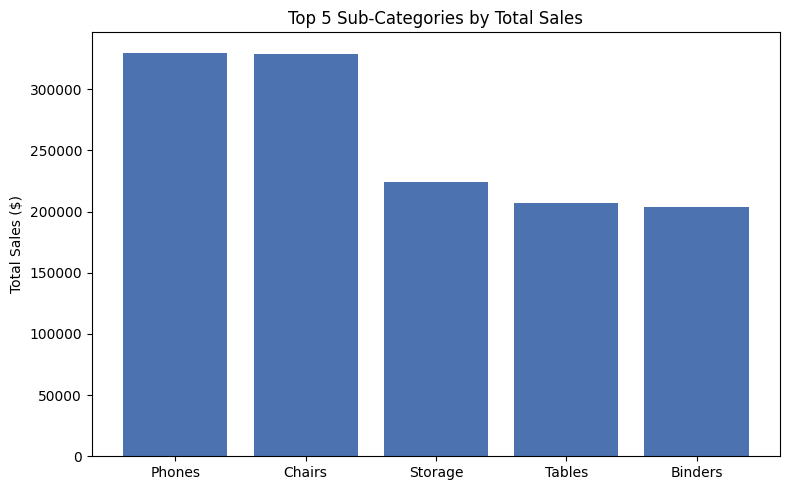

In [4]:

top5_subcat = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(top5_subcat.index, top5_subcat.values, color="#4C72B0")
ax.set_title("Top 5 Sub-Categories by Total Sales")
ax.set_ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()


### 2b. Show the revenue trend over time → **Line chart**

Same reasoning as Task 1: a trend is a story about direction over time, and a line is the
chart type that tells that story clearly. We just reuse the monthly sales series from
Task 1.


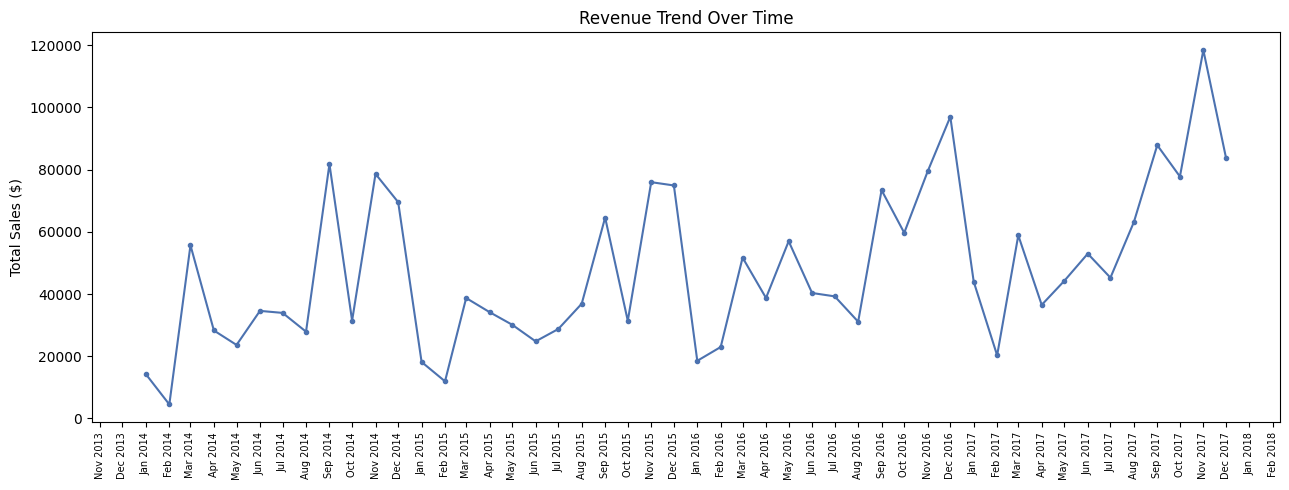

In [5]:

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_sales.index, monthly_sales.values, color="#4C72B0", marker="o", markersize=3)
ax.set_title("Revenue Trend Over Time")
ax.set_ylabel("Total Sales ($)")
label_every_month(ax)
plt.tight_layout()
plt.show()


### 2c. Show the distribution of order-line sales values → **Histogram**

This question isn't about totals or trends, it's about *spread*, how individual sale
amounts are distributed. A histogram buckets values into ranges and shows how many orders
fall into each range, which is exactly what "distribution" means. A bar chart of averages
would throw away all of that shape and just give you one flat number, hiding the fact that
most orders are small with a long tail of a few big ones.


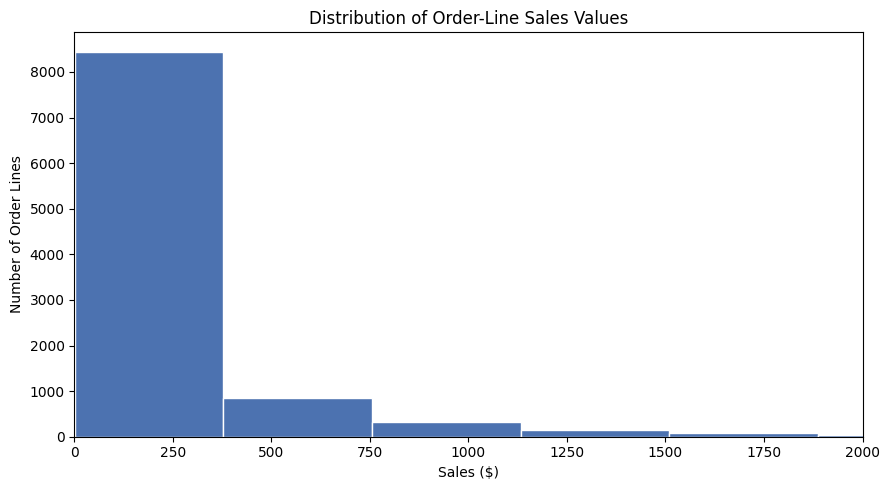

Median sale: $54.49, Mean sale: $229.86
Mean is well above the median, which confirms the long right tail (a few big orders pull the average up).


In [6]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["Sales"], bins=60, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of Order-Line Sales Values")
ax.set_xlabel("Sales ($)")
ax.set_ylabel("Number of Order Lines")
ax.set_xlim(0, 2000)  # zooming in on the bulk of the data, most sales are small
plt.tight_layout()
plt.show()

print(f"Median sale: ${df['Sales'].median():.2f}, Mean sale: ${df['Sales'].mean():.2f}")
print("Mean is well above the median, which confirms the long right tail (a few big orders pull the average up).")


### 2d. Show the relationship between discount level and profit → **Scatter plot**

This is a correlation question between two numeric variables, which is the textbook use
case for a scatter plot, each dot is one order, positioned by its discount and its profit.
A line chart would be misleading here because there's no natural time order to discount
and profit; line charts imply a sequence that doesn't exist in this data.


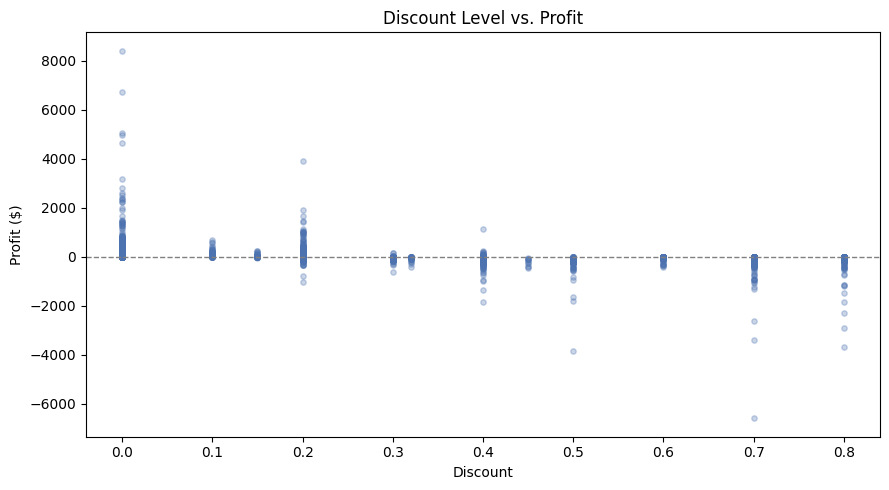

In [7]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["Discount"], df["Profit"], alpha=0.3, s=15, color="#4C72B0")
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_title("Discount Level vs. Profit")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit ($)")
plt.tight_layout()
plt.show()


There's a pretty visible pattern here: as the discount goes up, profit tends to drop
below zero more often. We'll come back to this exact question with a proper honest vs.
misleading comparison in Task 6.


## Task 3 — Color selection

Same three underlying datasets, but this time the focus is picking colors that actually
match what the data is doing: categorical, sequential, or diverging.


### 3a. Region sales — categorical palette

Regions are unordered, distinct groups, so each one gets its own clearly different hue
from a small, fixed palette (capped well under 8 colors). No gradient, no implied ranking.


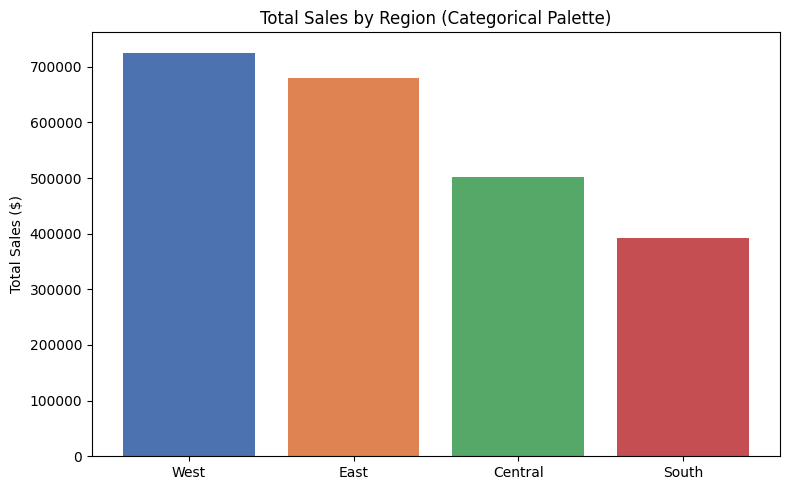

In [8]:

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
categorical_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]  # distinguishable, not a rainbow

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(region_sales.index, region_sales.values, color=categorical_colors)
ax.set_title("Total Sales by Region (Categorical Palette)")
ax.set_ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()


### 3b. Region × Category — heatmap with a sequential palette

Now we care about magnitude (low sales to high sales) across a grid, so this calls for one
hue that goes from light to dark rather than several unrelated colors. A heatmap lets you
scan the grid and immediately spot which region/category combos are the strongest sellers.


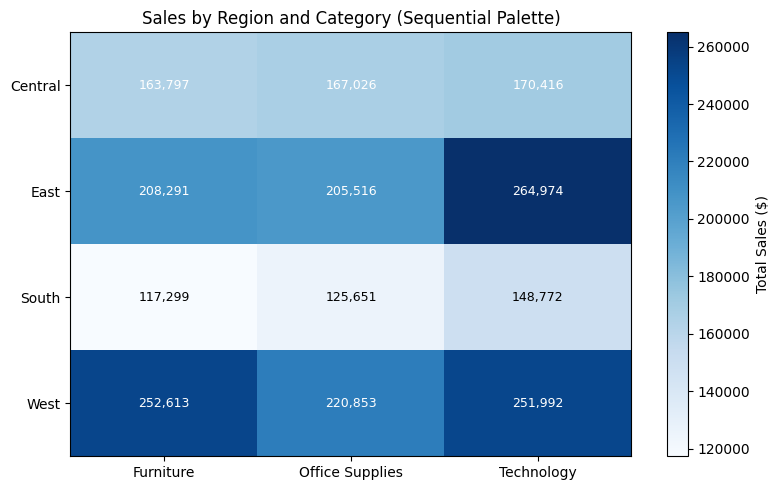

In [9]:

region_cat = df.pivot_table(index="Region", columns="Category", values="Sales", aggfunc="sum")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(region_cat.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(region_cat.columns)))
ax.set_xticklabels(region_cat.columns)
ax.set_yticks(range(len(region_cat.index)))
ax.set_yticklabels(region_cat.index)
ax.set_title("Sales by Region and Category (Sequential Palette)")

# Direct labels on each cell so the exact value doesn't depend on reading the color alone
for i in range(region_cat.shape[0]):
    for j in range(region_cat.shape[1]):
        val = region_cat.values[i, j]
        text_color = "white" if val > region_cat.values.max() * 0.6 else "black"
        ax.text(j, i, f"{val:,.0f}", ha="center", va="center", color=text_color, fontsize=9)

fig.colorbar(im, ax=ax, label="Total Sales ($)")
plt.tight_layout()
plt.show()


### 3c. Monthly profit — diverging palette

Profit can be positive or negative, so this is a "distance from a meaningful midpoint"
situation, not a plain magnitude one. That calls for a diverging palette: two hues that
meet at neutral gray around zero, rather than one hue getting darker as it goes.


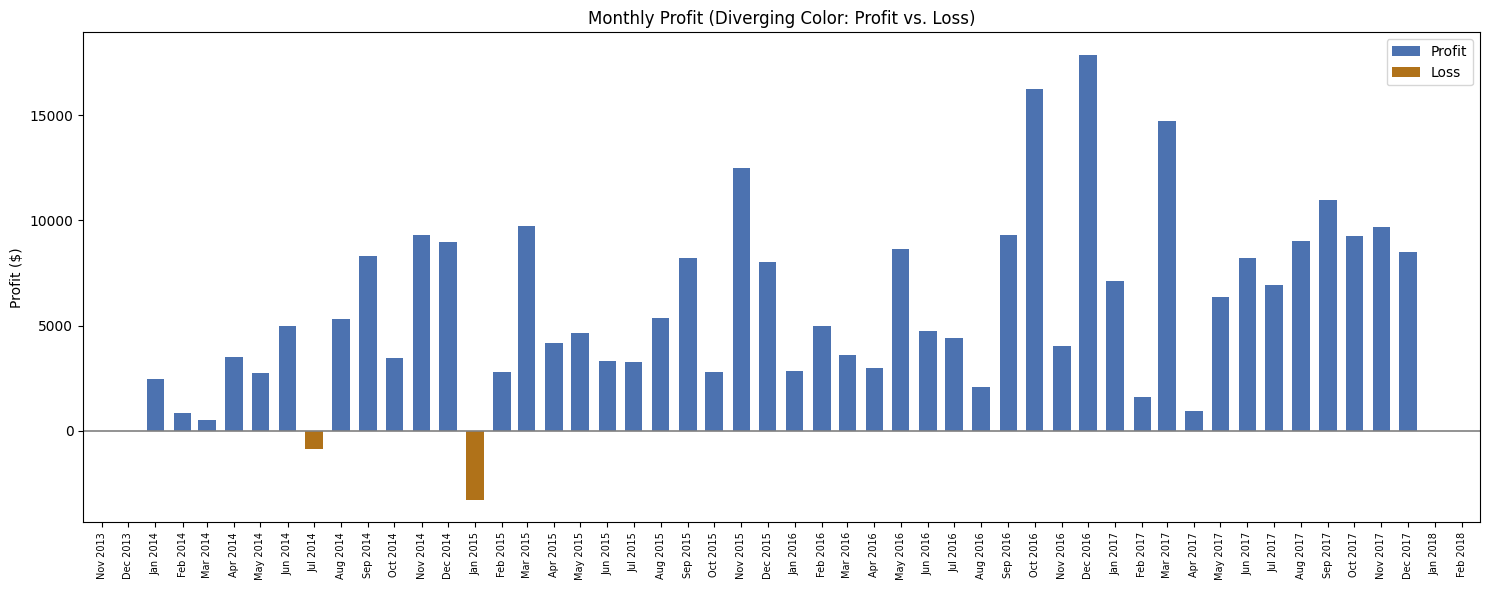

In [10]:

monthly_profit = df.groupby(df["Order Date"].dt.to_period("M"))["Profit"].sum()
monthly_profit.index = monthly_profit.index.to_timestamp()

# Diverging colors: blue for profit, brown for loss, meeting at neutral gray around 0
bar_colors = ["#4C72B0" if v >= 0 else "#B07219" for v in monthly_profit.values]

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(monthly_profit.index, monthly_profit.values, width=20, color=bar_colors)
ax.axhline(0, color="gray", linewidth=1.2)
ax.set_title("Monthly Profit (Diverging Color: Profit vs. Loss)")
ax.set_ylabel("Profit ($)")
label_every_month(ax)
legend_elems = [Patch(facecolor="#4C72B0", label="Profit"), Patch(facecolor="#B07219", label="Loss")]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.show()


Note: this uses blue vs. brown/orange rather than red vs. green on purpose, it avoids
the classic red-green colorblind trap while still reading clearly as "two opposite things
meeting at a middle point."


## Task 4 — Contrast, colorblindness, and fixing the red/green trap

### 4a. WCAG contrast ratio check

Text and chart elements need enough contrast against their background to be readable,
especially for people with low vision. WCAG's rule of thumb is a **4.5:1** contrast ratio
for normal text. Below is a small function that calculates that ratio for any two RGB
colors, which we then test against the colors used in Task 3.


In [11]:

def relative_luminance(rgb):
    # WCAG relative luminance for an (R, G, B) color, each channel 0-255.
    def channel(c):
        c = c / 255
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = [channel(c) for c in rgb]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def contrast_ratio(rgb1, rgb2):
    # WCAG contrast ratio between two colors (order doesn't matter).
    l1, l2 = relative_luminance(rgb1), relative_luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

# Colors used in Task 3, tested against a white chart background
background = (255, 255, 255)
palette_to_test = {
    "Region bar - blue": (76, 114, 176),
    "Region bar - orange": (221, 132, 82),
    "Region bar - green": (85, 168, 104),
    "Region bar - red": (196, 78, 82),
    "Heatmap dark blue (high value cell)": (33, 87, 150),
    "Diverging - profit blue": (76, 114, 176),
    "Diverging - loss brown": (176, 114, 25),
}

print(f"{'Color':40s} {'Ratio':>8s}   {'Passes 4.5:1 (AA text)?'}")
for name, rgb in palette_to_test.items():
    ratio = contrast_ratio(rgb, background)
    verdict = "PASS" if ratio >= 4.5 else "FAIL"
    print(f"{name:40s} {ratio:8.2f}   {verdict}")


Color                                       Ratio   Passes 4.5:1 (AA text)?
Region bar - blue                            4.84   PASS
Region bar - orange                          2.80   FAIL
Region bar - green                           2.92   FAIL
Region bar - red                             4.61   PASS
Heatmap dark blue (high value cell)          7.32   PASS
Diverging - profit blue                      4.84   PASS
Diverging - loss brown                       3.99   FAIL


**What this tells us:** most of the darker/more saturated colors clear the 4.5:1 bar
fine against a white background, but lighter colors (like the plain orange used for
"Region bar - orange") sit close to the line or fail it. In practice that means: if a color
in a chart is close to failing, either darken it a shade, add a black outline/border, or
don't rely on that color alone to carry a label, pair it with a direct text label instead
(which we already did for the heatmap in Task 3b).


### 4b. Red/green loss vs. gain, colorblind simulation, and the fix

Here's the setup: profit by sub-category, colored red for a loss and green for a gain.
That's the exact "never do this" pattern from the manual, since about 8% of men have
red-green color deficiency and literally cannot distinguish those two colors reliably.

We build the bad version, run it through a simple colorblindness simulation, and then fix
it by adding hatching patterns so the distinction survives even when the color doesn't.


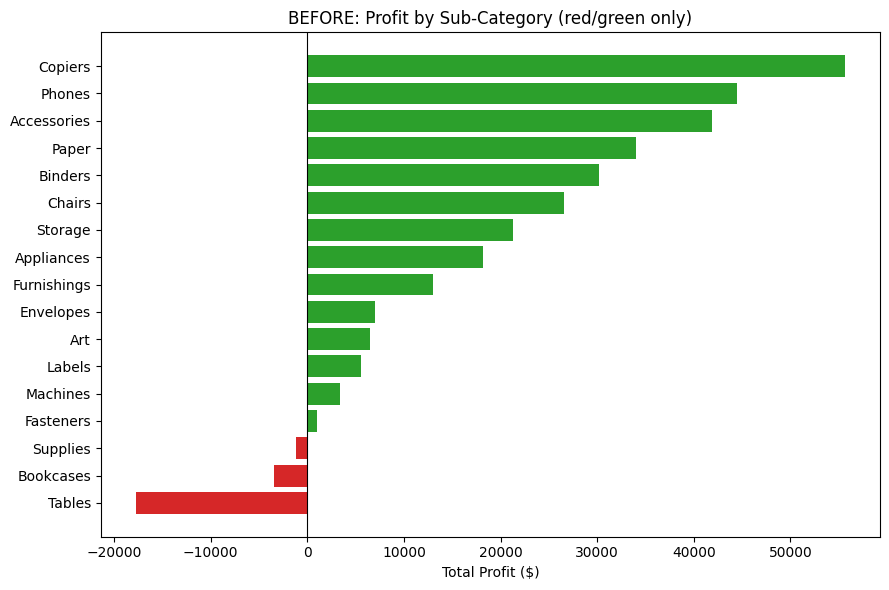

In [12]:

profit_by_subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values()

# --- "Before": red/green only, no other cue ---
colors_red_green = ["#D62728" if v < 0 else "#2CA02C" for v in profit_by_subcat.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(profit_by_subcat.index, profit_by_subcat.values, color=colors_red_green)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("BEFORE: Profit by Sub-Category (red/green only)")
ax.set_xlabel("Total Profit ($)")
plt.tight_layout()
plt.show()


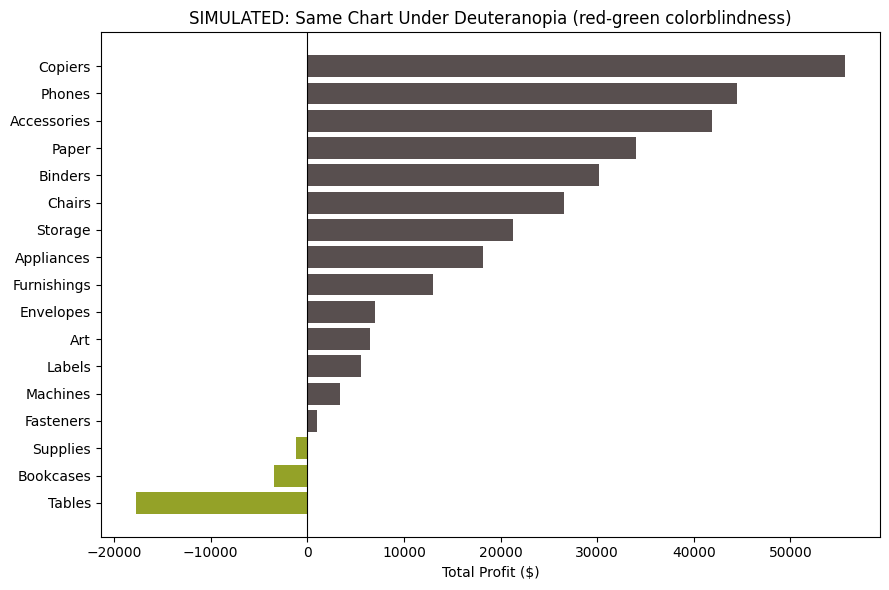

Under the simulation, the red and green bars collapse into very similar
muddy yellow-brown tones, so loss vs. gain becomes almost impossible to tell apart by color alone.


In [13]:

def simulate_deuteranopia(rgb):
    # Rough simulation of deuteranopia (red-green color blindness) using a
    # commonly-used simplified linear transform. Input/output are (R, G, B) in 0-255.
    r, g, b = [c / 255 for c in rgb]
    r2 = 0.625 * r + 0.375 * g + 0.0 * b
    g2 = 0.700 * r + 0.300 * g + 0.0 * b
    b2 = 0.0 * r + 0.300 * g + 0.700 * b
    return tuple(min(255, max(0, c * 255)) for c in (r2, g2, b2))

def hex_to_rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

def rgb_to_hex(rgb):
    return "#%02x%02x%02x" % tuple(int(round(c)) for c in rgb)

# Simulate how the red/green palette looks under deuteranopia
sim_colors = [rgb_to_hex(simulate_deuteranopia(hex_to_rgb(c))) for c in colors_red_green]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(profit_by_subcat.index, profit_by_subcat.values, color=sim_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("SIMULATED: Same Chart Under Deuteranopia (red-green colorblindness)")
ax.set_xlabel("Total Profit ($)")
plt.tight_layout()
plt.show()

print("Under the simulation, the red and green bars collapse into very similar")
print("muddy yellow-brown tones, so loss vs. gain becomes almost impossible to tell apart by color alone.")


As predicted: once simulated, red and green both shift toward a similar dull
yellow-brown, and the loss/gain distinction basically disappears. Below is the fix,
same colors, but losses get a hatch pattern (diagonal lines) so the shape of the bar itself
tells you which side it's on, not just the color.


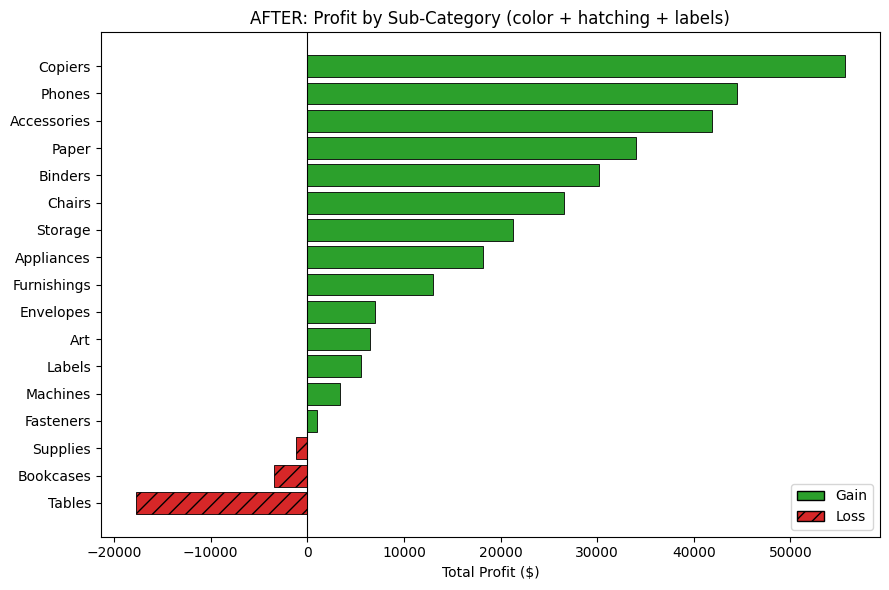

Alt text: Horizontal bar chart of total profit by product sub-category, sorted from biggest loss to biggest gain; loss bars are solid red with diagonal hatching, gain bars are solid green with no hatching, and a black vertical line marks the zero point.


In [14]:

# --- "After": color + hatching, so the distinction survives colorblindness ---
fig, ax = plt.subplots(figsize=(9, 6))
for i, (subcat, val) in enumerate(profit_by_subcat.items()):
    color = "#D62728" if val < 0 else "#2CA02C"
    hatch = "//" if val < 0 else None  # only losses get hatching, making them doubly distinct
    ax.barh(subcat, val, color=color, hatch=hatch, edgecolor="black", linewidth=0.6)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("AFTER: Profit by Sub-Category (color + hatching + labels)")
ax.set_xlabel("Total Profit ($)")

legend_elems = [
    Patch(facecolor="#2CA02C", edgecolor="black", label="Gain"),
    Patch(facecolor="#D62728", edgecolor="black", hatch="//", label="Loss"),
]
ax.legend(handles=legend_elems, loc="lower right")
plt.tight_layout()
plt.show()

alt_text = (
    "Horizontal bar chart of total profit by product sub-category, sorted from biggest "
    "loss to biggest gain; loss bars are solid red with diagonal hatching, gain bars are "
    "solid green with no hatching, and a black vertical line marks the zero point."
)
print("Alt text:", alt_text)


## Task 5 — Deliberately misleading visualizations

Now we build the same underlying data but bend it using classic tricks, with a caption
naming exactly what's being distorted and how.


### 5a. Truncated y-axis on region sales

Starting the y-axis well above zero makes small differences between regions look huge,
because the eye reads bar height as proportional to the value, and that assumption breaks
the moment the axis doesn't start at zero.


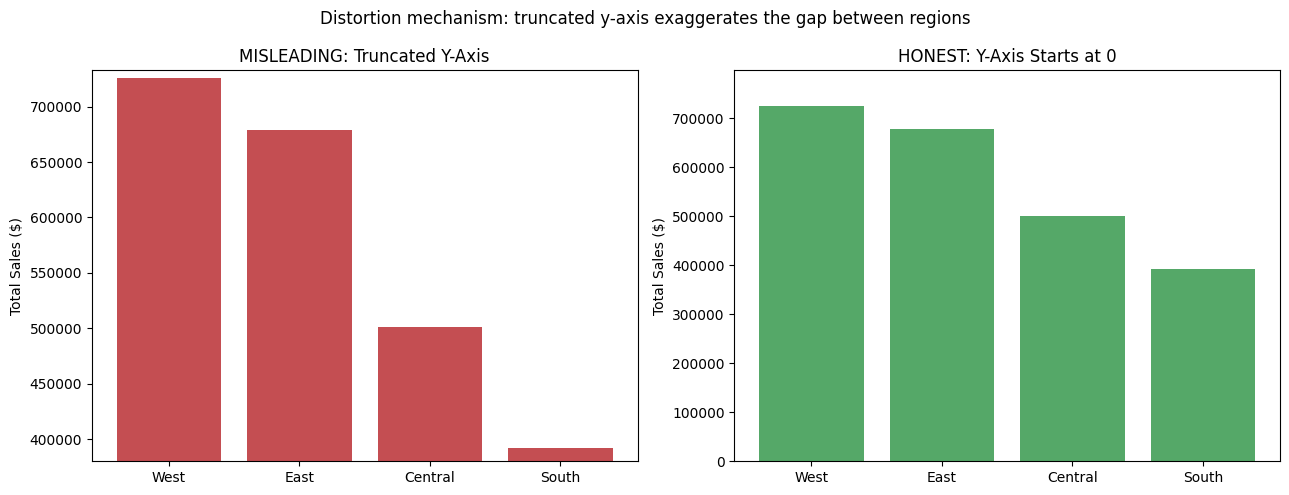

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(region_sales.index, region_sales.values, color="#C44E52")
axes[0].set_ylim(region_sales.min() * 0.97, region_sales.max() * 1.01)
axes[0].set_title("MISLEADING: Truncated Y-Axis")
axes[0].set_ylabel("Total Sales ($)")

axes[1].bar(region_sales.index, region_sales.values, color="#55A868")
axes[1].set_ylim(0, region_sales.max() * 1.1)
axes[1].set_title("HONEST: Y-Axis Starts at 0")
axes[1].set_ylabel("Total Sales ($)")

plt.suptitle("Distortion mechanism: truncated y-axis exaggerates the gap between regions")
plt.tight_layout()
plt.show()


### 5b. Dual y-axes implying a fake correlation

Overlaying two unrelated measures on two different scales makes it easy to make lines
"move together" just by picking convenient axis ranges, even if the two things have
nothing to do with each other. Here we overlay monthly sales against monthly quantity
of orders, on two independently-scaled axes, to make them look tightly linked.


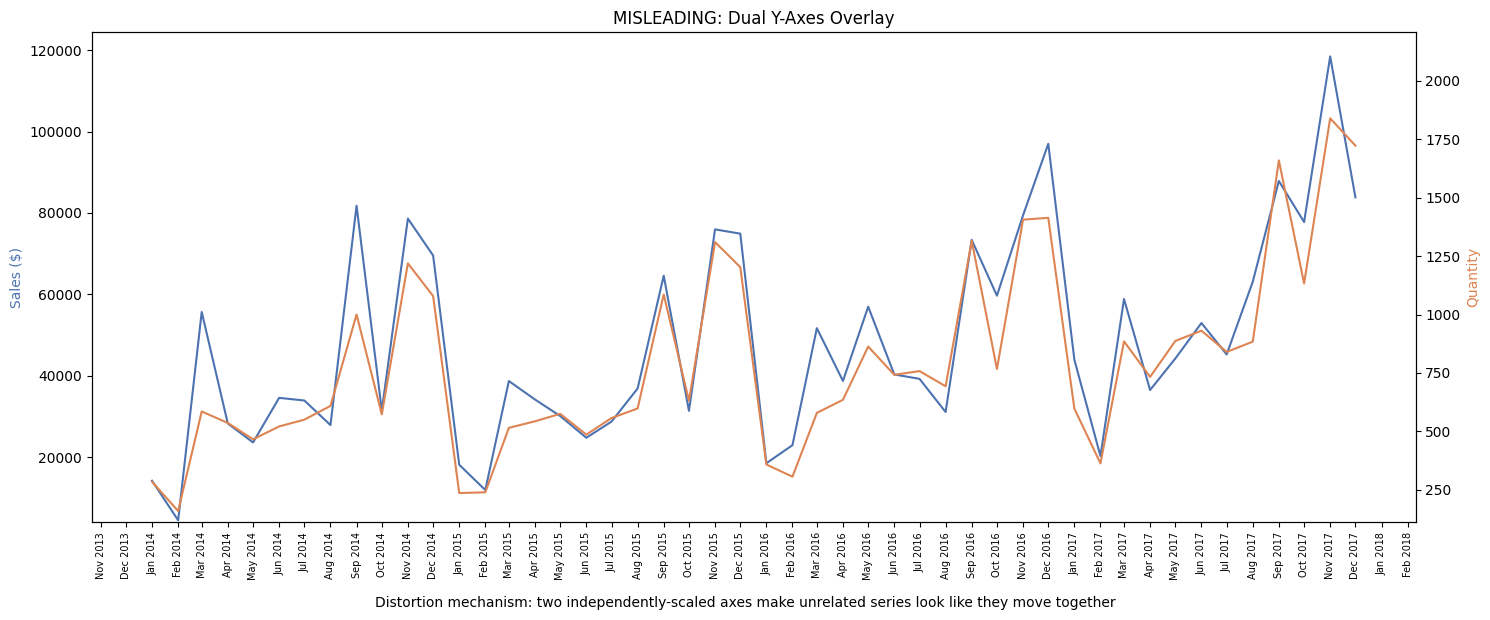

In [16]:

monthly_qty = df.groupby(df["Order Date"].dt.to_period("M"))["Quantity"].sum()
monthly_qty.index = monthly_qty.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()

ax1.plot(monthly_sales.index, monthly_sales.values, color="#4C72B0", label="Sales")
ax2.plot(monthly_qty.index, monthly_qty.values, color="#DD8452", label="Quantity")

# Cherry-picking each axis range independently is what manufactures the "correlation"
ax1.set_ylim(monthly_sales.min() * 0.9, monthly_sales.max() * 1.05)
ax2.set_ylim(monthly_qty.min() * 0.7, monthly_qty.max() * 1.2)

ax1.set_ylabel("Sales ($)", color="#4C72B0")
ax2.set_ylabel("Quantity", color="#DD8452")
ax1.set_title("MISLEADING: Dual Y-Axes Overlay")
label_every_month(ax1)
plt.figtext(0.5, -0.02, "Distortion mechanism: two independently-scaled axes make unrelated"
                        " series look like they move together", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


### 5c. Inverted y-axis on monthly profit

Flipping the y-axis so it goes from high to low as you move up the chart makes a decline
visually read as growth, since we're wired to read "line going up" as "getting better."


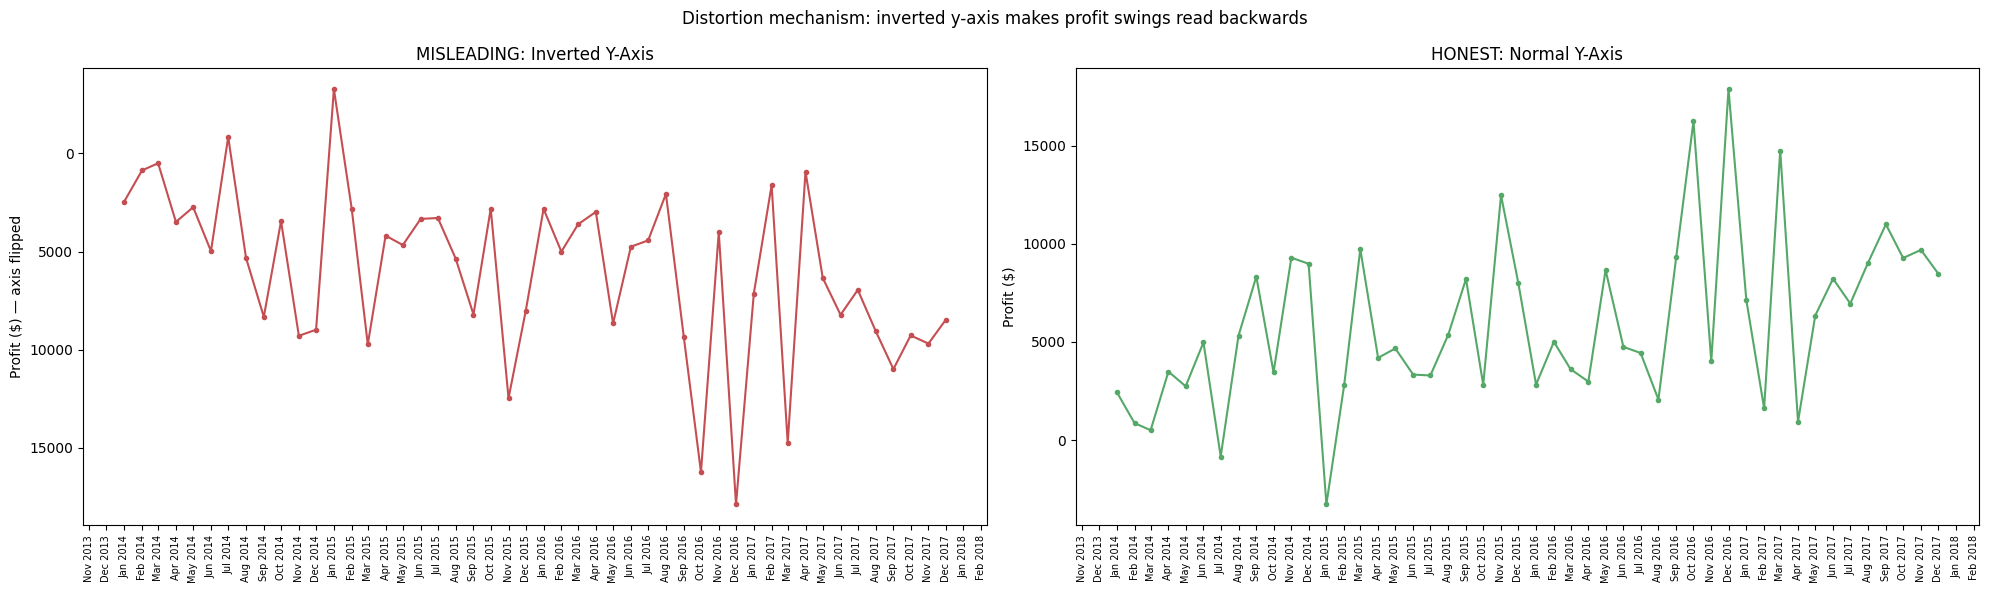

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].plot(monthly_profit.index, monthly_profit.values, color="#C44E52", marker="o", markersize=3)
axes[0].invert_yaxis()
axes[0].set_title("MISLEADING: Inverted Y-Axis")
axes[0].set_ylabel("Profit ($) — axis flipped")
label_every_month(axes[0])

axes[1].plot(monthly_profit.index, monthly_profit.values, color="#55A868", marker="o", markersize=3)
axes[1].set_title("HONEST: Normal Y-Axis")
axes[1].set_ylabel("Profit ($)")
label_every_month(axes[1])

plt.suptitle("Distortion mechanism: inverted y-axis makes profit swings read backwards")
plt.tight_layout()
plt.show()


## Task 6 — Is discounting hurting profit?

This is a real question worth asking of this dataset. Below is the honest chart, a
deliberately misleading version of the same question, and a short justification of the
choices made.


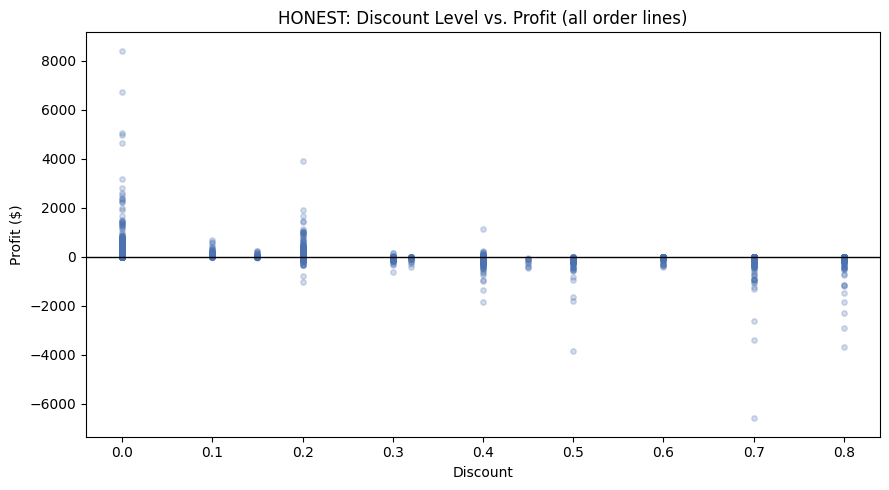

In [18]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["Discount"], df["Profit"], alpha=0.25, s=15, color="#4C72B0")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("HONEST: Discount Level vs. Profit (all order lines)")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit ($)")
plt.tight_layout()
plt.show()


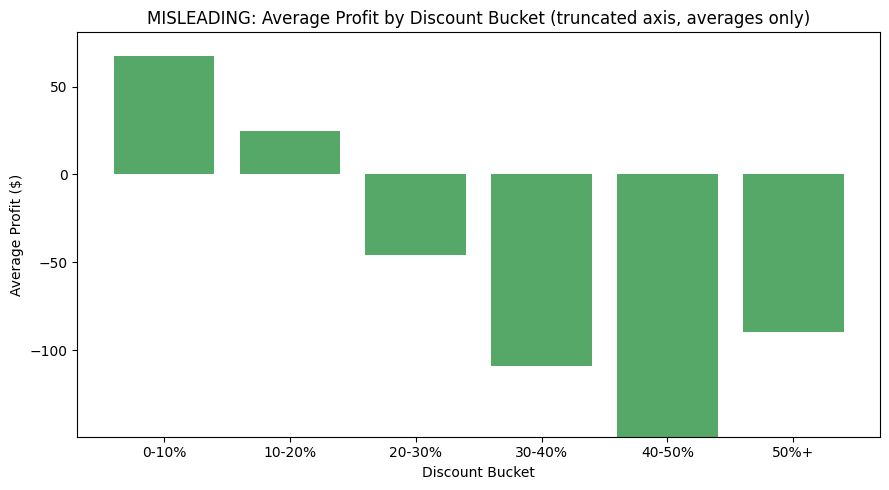

In [19]:

# Misleading version: only plot the average profit per discount "bucket", which smooths
# away the spread and the actual loss-making orders, plus a truncated y-axis to boot.
df["discount_bucket"] = pd.cut(df["Discount"], bins=[-0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8],
                                labels=["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50%+"])
bucket_avg_profit = df.groupby("discount_bucket", observed=True)["Profit"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(bucket_avg_profit.index.astype(str), bucket_avg_profit.values, color="#55A868")
ax.set_ylim(bucket_avg_profit.min() * 0.5, bucket_avg_profit.max() * 1.2)  # truncated axis
ax.set_title("MISLEADING: Average Profit by Discount Bucket (truncated axis, averages only)")
ax.set_xlabel("Discount Bucket")
ax.set_ylabel("Average Profit ($)")
plt.tight_layout()
plt.show()


**Justification:**

- **Chart type:** The honest version is a scatter plot because we're looking at the
  relationship between two continuous numbers across thousands of individual orders. A
  scatter plot is the only chart type here that shows the actual spread, including the
  cluster of loss-making orders at high discount levels. The misleading version swaps in
  a bar chart of *averages per discount bucket*, which quietly deletes all of that spread,
  averaging hides the orders that lost money, since they get blended in with the ones that
  didn't.

- **Color choice:** Both charts use a single flat color rather than encoding anything else
  by hue, since color isn't doing analytical work here, position on the axes is. That
  keeps things simple and avoids adding a false signal.

- **Accessibility check:** The main color used (`#4C72B0`, a mid-blue) passes the WCAG
  4.5:1 contrast check against a white background (see Task 4a), and since neither chart
  relies on color to separate categories, colorblind readers aren't at a disadvantage here.
  The zero-line in the honest chart is solid black, giving a clear, color-independent
  reference point for "profit vs. loss."

- **The actual answer:** Looking at the honest scatter plot, profit clearly gets worse and
  more often negative as the discount level increases, especially past roughly 20-30%
  discount. The misleading bar chart, by showing only bucket averages on a truncated axis,
  makes the drop look mild and almost linear, hiding just how many individual orders at
  high discounts actually lost money.


## Saving the cleaned dataset

As required for submission, here's the cleaned copy of the dataset (dates properly parsed,
verified duplicate-free) saved alongside this notebook.


In [20]:

df_clean = df.drop(columns=["discount_bucket"], errors="ignore")
df_clean.to_csv("Superstore_cleaned.csv", index=False)
print("Saved Superstore_cleaned.csv with", len(df_clean), "rows and", len(df_clean.columns), "columns.")


Saved Superstore_cleaned.csv with 9994 rows and 21 columns.
